# LAB 05.02 - Model evaluation

In [1]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/rramosp/ai4eng.v1/main/content/init.py
import init; init.init(force_download=False); init.get_weblink()


replicating local resources


In [35]:
from local.lib.rlxmoocapi import submit, session
session.LoginSequence(endpoint=init.endpoint, session_id='2025.2',course_id=init.course_id, lab_id="L05.02", varname="student");

logging in as santiago.herrera6@udea.edu.co... please wait
you are registered in the following sessions of this course

     ['2025.2', 'open']

and you have explicitly requested session '2025.2'.
your grades will be reported in that session

-------------
using course session ai4eng.v1.udea.r3::2025.2
success!! you are logged in
-------------


## Task 1: Partition randomly `numpy` arrays

observe we can select specific rows and/or columns on a numpy array

In [3]:
import numpy as np

x = np.random.randint(100, size=(20,5))
x[:,0] = range(len(x))
x[0,:] = range(x.shape[1])
x

array([[ 0,  1,  2,  3,  4],
       [ 1, 31, 50, 96, 38],
       [ 2, 35, 81, 32, 95],
       [ 3, 14, 97, 49, 99],
       [ 4, 52,  0, 35, 93],
       [ 5,  1,  3, 40, 93],
       [ 6,  0, 22, 81, 40],
       [ 7, 23,  5, 36, 41],
       [ 8, 89, 78, 27, 92],
       [ 9, 21, 10, 95, 33],
       [10,  1,  3, 28, 68],
       [11, 80, 80, 77, 90],
       [12, 53, 40, 89, 74],
       [13, 47, 97,  6, 32],
       [14, 56, 13, 54, 52],
       [15, 39, 92, 13, 13],
       [16, 90, 60,  8, 46],
       [17, 65, 38, 65, 24],
       [18, 61, 22, 94, 87],
       [19, 72, 27,  1, 42]])

In [4]:
ridxs = np.r_[2,4,5]
x[ridxs]

array([[ 2, 35, 81, 32, 95],
       [ 4, 52,  0, 35, 93],
       [ 5,  1,  3, 40, 93]])

In [5]:
cidxs = np.r_[1,3]
x[:,cidxs]

array([[ 1,  3],
       [31, 96],
       [35, 32],
       [14, 49],
       [52, 35],
       [ 1, 40],
       [ 0, 81],
       [23, 36],
       [89, 27],
       [21, 95],
       [ 1, 28],
       [80, 77],
       [53, 89],
       [47,  6],
       [56, 54],
       [39, 13],
       [90,  8],
       [65, 65],
       [61, 94],
       [72,  1]])

In [6]:
x[ridxs][:, cidxs]

array([[35, 32],
       [52, 35],
       [ 1, 40]])

and the dimensions of the array are accessible through `len` and `shape`

In [7]:
len(x), x.shape

(20, (20, 5))

observe also how we can partition it

In [8]:
x[:3]

array([[ 0,  1,  2,  3,  4],
       [ 1, 31, 50, 96, 38],
       [ 2, 35, 81, 32, 95]])

In [9]:
x[3:]

array([[ 3, 14, 97, 49, 99],
       [ 4, 52,  0, 35, 93],
       [ 5,  1,  3, 40, 93],
       [ 6,  0, 22, 81, 40],
       [ 7, 23,  5, 36, 41],
       [ 8, 89, 78, 27, 92],
       [ 9, 21, 10, 95, 33],
       [10,  1,  3, 28, 68],
       [11, 80, 80, 77, 90],
       [12, 53, 40, 89, 74],
       [13, 47, 97,  6, 32],
       [14, 56, 13, 54, 52],
       [15, 39, 92, 13, 13],
       [16, 90, 60,  8, 46],
       [17, 65, 38, 65, 24],
       [18, 61, 22, 94, 87],
       [19, 72, 27,  1, 42]])

we can do the same thing with vectors

In [10]:
v = np.arange(100,120)
v

array([100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112,
       113, 114, 115, 116, 117, 118, 119])

In [11]:
v[:5], v[5:]

(array([100, 101, 102, 103, 104]),
 array([105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
        118, 119]))

finally, observe how we can create a random permutation of a specific vector

In [12]:
np.random.permutation(v)

array([107, 110, 115, 119, 112, 100, 103, 106, 113, 118, 101, 109, 116,
       104, 114, 111, 105, 108, 117, 102])

or the first natural numbers

In [15]:
p = np.random.permutation(20)
p

array([ 5,  6, 10, 12,  3, 18, 11,  9,  8, 19, 17, 15,  7, 14,  0,  2,  4,
       13, 16,  1])

how do you interpret this?

In [16]:
v[p[5:]]

array([118, 111, 109, 108, 119, 117, 115, 107, 114, 100, 102, 104, 113,
       116, 101])

In [17]:
x[p[:5]]

array([[ 5,  1,  3, 40, 93],
       [ 6,  0, 22, 81, 40],
       [10,  1,  3, 28, 68],
       [12, 53, 40, 89, 74],
       [ 3, 14, 97, 49, 99]])

### assignment

in this task you will have to complete the function  `split_data` below so that:

- it accepts two arguments `X` and `y`, either of which can be any numpy array (1D, 2D, etc.) of the **same** size $n$ (observe the  `assert` statement), and a `pct`
- creates a random permutation of the natural number from $0$ to $n-1$
- partitions the permutations so that the first partition contains the first `n1_elements` $=$ `int(n * pct)` numbers, and the second partition the rest
- interpret the permutation partitions components as indexes to `X` and `y` so that they are partitioned into `X1`, `X2` and `y1`, `y2` respectively

note that **indexes to array** must be of type `int`. do the following to convert a float to int

In [18]:
a,b = 10,.3
c = a*b
print (c)
c = int(c)
print(c)

3.0
3


In [20]:
def split_data(X, y, pct):

    assert len(X)==len(y), "X and y must have the same length"
    assert pct>0 and pct<1, "pct must be in the (0,1) iterval"

    n = len(X)
    n1_elements = int(n * pct)
    permutation = np.arange(n)

    permutation_partition_1 = permutation[:n1_elements]
    permutation_partition_2 = permutation[n1_elements:]

    X1 = X[permutation_partition_1]
    X2 = X[permutation_partition_2]
    y1 = y[permutation_partition_1]
    y2 = y[permutation_partition_2]

    return X1, X2, y1, y2

check your solution manually with the following code

In [21]:
XX = np.random.randint(100, size=(20,8))
yy = np.arange(100,100+len(XX))
XX[:,0] = range(len(XX))
XX[0,:] = range(XX.shape[1])
print (XX)
print (yy)

[[ 0  1  2  3  4  5  6  7]
 [ 1 48 98 64 92 37 78 53]
 [ 2  0 21 17 19 56 65 81]
 [ 3 30 67 60 78 59 73 77]
 [ 4 52  5 33 26  5 60 29]
 [ 5 32 47 27 86 99 49 14]
 [ 6 66  1 28 37 70  6 16]
 [ 7 24 26 56 28 25  3  6]
 [ 8 56 25 33 82 66 21 83]
 [ 9 24 10 19 44 21 10 52]
 [10 54 11 50 71 30 85 76]
 [11 16 15 15  4 52 89 84]
 [12 94 31 79 83 27 69 83]
 [13 50 13 30 30 37 29 23]
 [14 64  7 22 18 26 77 47]
 [15 69 99 19  4 75 40 57]
 [16 89 66 37 13 27 17 61]
 [17 90 86 65 44  8 65 18]
 [18 87 99 28 65 66 18 48]
 [19 16 39  6 60 47 35 52]]
[100 101 102 103 104 105 106 107 108 109 110 111 112 113 114 115 116 117
 118 119]


In [22]:
Xtr, Xts, ytr, yts = split_data(XX, yy, pct=.7)

In [23]:
# check partition ok
np.sum(XX), np.sum(Xtr) + np.sum(Xts), np.sum(yy), np.sum(ytr)+np.sum(yts)

(np.int64(6199), np.int64(6199), np.int64(2190), np.int64(2190))

In [24]:
print (Xtr, "\n--")
print (Xts, "\n--")
print (ytr, "\n--")
print (yts, "\n--")

[[ 0  1  2  3  4  5  6  7]
 [ 1 48 98 64 92 37 78 53]
 [ 2  0 21 17 19 56 65 81]
 [ 3 30 67 60 78 59 73 77]
 [ 4 52  5 33 26  5 60 29]
 [ 5 32 47 27 86 99 49 14]
 [ 6 66  1 28 37 70  6 16]
 [ 7 24 26 56 28 25  3  6]
 [ 8 56 25 33 82 66 21 83]
 [ 9 24 10 19 44 21 10 52]
 [10 54 11 50 71 30 85 76]
 [11 16 15 15  4 52 89 84]
 [12 94 31 79 83 27 69 83]
 [13 50 13 30 30 37 29 23]] 
--
[[14 64  7 22 18 26 77 47]
 [15 69 99 19  4 75 40 57]
 [16 89 66 37 13 27 17 61]
 [17 90 86 65 44  8 65 18]
 [18 87 99 28 65 66 18 48]
 [19 16 39  6 60 47 35 52]] 
--
[100 101 102 103 104 105 106 107 108 109 110 111 112 113] 
--
[114 115 116 117 118 119] 
--


In [ ]:
Xts

**submit your code**

In [25]:
student.submit_task(globals(), task_id="task_01");


## Task 2: Fit a model and make predictions

observe how we create new data from synthetic datasets available in `sklearn`

In [26]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from local.lib import mlutils
%matplotlib inline

/content/local/lib/mlutils.py:445: SyntaxWarning: invalid escape sequence '\m'
  time_str = "fit time  (TRAIN)    %.2f $\mu$secs"%(fitting_time*1000)


In [27]:
X, y = make_moons(200, noise=0.2)
X.shape, y.shape

((200, 2), (200,))

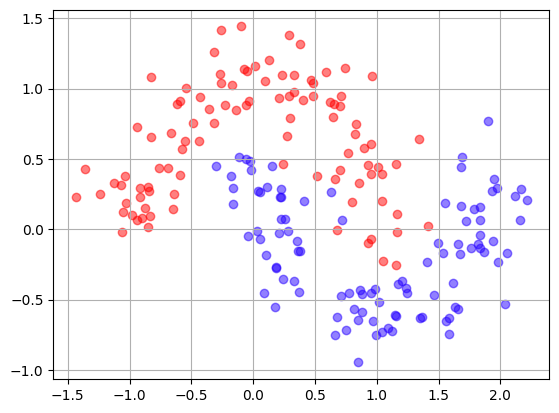

In [28]:
mlutils.plot_2Ddata(X,y); plt.grid();

observe also how we create an algorithm instance and fit a model

(np.float64(0.507025), np.float64(0.492975))

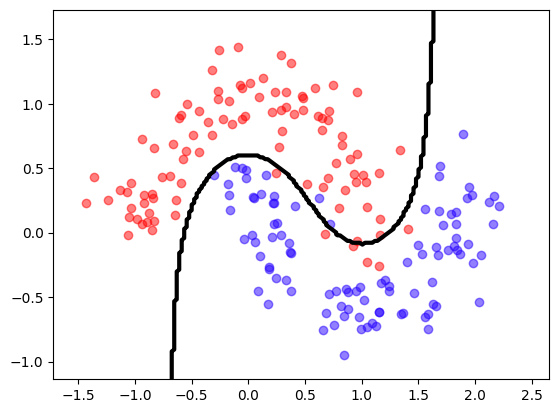

In [29]:
from sklearn.svm import SVC
estimator = SVC(gamma=1)
estimator.fit(X,y)
mlutils.plot_2Ddata_with_boundary(estimator.predict, X, y)

and how we make predictions

In [30]:
preds = estimator.predict(X)
print (preds.shape)
preds

(200,)


array([1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1,
       0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0,
       1, 0])

in this task you have to complete the following function so that:

- it makes two non-random partitions of `X` and `y`. One containing the first half of the data and one containing the second part. If the number of elements of `X` is odd, then the second half will contain one more element than the first half.
- it fits the model with the first part of the data
- it makes predictions on the second half of the data
- returns the estimator fitted, and the predictions on the second half of the data.

In [31]:
def fit_and_predict(estimator, X, y):
    assert len(X)==len(y), "X and y must have the same length"

    n = len(X)
    split_idx = n // 2

    X_tr, X_ts = X[:split_idx], X[split_idx:]
    y_tr, y_ts = y[:split_idx], y[split_idx:]

    estimator.fit(X_tr, y_tr)

    predictions = estimator.predict(X_ts)

    return estimator, predictions

check your code. your predictions should be similar to

    preds
    >> array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

In [32]:
X = np.array([[ 0.74799424, -0.5867667 ],
       [-0.64457753,  1.25127894],
       [ 0.53682593,  0.10931563],
       [-0.88825294, -0.06987509],
       [ 0.99612638, -0.52295157],
       [ 1.20586692,  0.01930477],
       [-0.19368482,  0.65121567],
       [ 0.1973759 ,  0.82250723],
       [ 0.94859234, -0.5457241 ],
       [ 1.87967948, -0.22740261],
       [ 0.58766146,  0.3982837 ],
       [ 0.27731571,  1.14369568],
       [-0.67421956,  0.12785382],
       [ 0.56957459,  1.05330376],
       [ 1.52435938, -0.29864338],
       [-0.15973608,  0.21790711],
       [ 1.59037406, -0.56875485],
       [ 0.43257507, -0.48900315],
       [ 1.09440413, -0.73789029],
       [-0.32940869,  0.74671384]])
y = np.array([1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0])
X.shape, y.shape

((20, 2), (20,))

In [33]:
from sklearn.linear_model import LogisticRegression
estimator = LogisticRegression()
estimator, preds = fit_and_predict(estimator, X, y)
preds

array([0, 0, 0, 0, 1, 0, 1, 1, 1, 0])

**submit your code**

In [36]:
student.submit_task(globals(), task_id="task_02");


## Task 3: Select data with indices

Observe how we can create a vector or matrix of `True/False` (boolean) by applying a condition to any matrix or vector

In [37]:
import numpy as np
y = np.random.randint(10, size=15)
print (y)

[2 9 6 7 5 8 9 0 2 1 8 0 0 5 9]


In [38]:
y_less_than_5 = y<5
print (y_less_than_5)

[ True False False False False False False  True  True  True False  True
  True False False]


and how we can select elements of a vector using a boolean vector of the same length

In [39]:
y[y_less_than_5]

array([2, 0, 2, 1, 0, 0])

In [40]:
y[y<5]

array([2, 0, 2, 1, 0, 0])

python doesn't really care how you construct the vector of booleans to index any other vector or array

In [41]:
v = np.random.randint(20, size=15)
v

array([17,  4, 14, 12, 10, 15, 11, 10,  0, 14, 15, 17, 10, 11, 11])

In [42]:
v[y<5]

array([17, 10,  0, 14, 17, 10])

in this task you will complete the function `select_per_class` such that:

- receives an array of data `X` and a vector of labels `y`, of the same length
- the labels `y` are binary, they can only have values `0` or `1`
- makes two partitions of `X`, one corresponding to the places where y is 0, and another where y is 1
- returns the two partitions

For instance, for the following X and y

    X = np.array([[8, 8, 5, 2, 0, 0],
                  [4, 4, 8, 1, 3, 7],
                  [4, 5, 3, 6, 9, 6],
                  [0, 3, 5, 3, 5, 3],
                  [0, 7, 2, 7, 1, 7],
                  [5, 7, 7, 1, 8, 5],
                  [2, 5, 7, 3, 8, 0],
                  [7, 2, 5, 9, 8, 7],
                  [1, 6, 6, 1, 6, 0],
                  [0, 7, 6, 5, 3, 4]])

    y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

your function must return the following two matrices:

    [[8 8 5 2 0 0]
     [4 4 8 1 3 7]
     [4 5 3 6 9 6]
     [0 3 5 3 5 3]
     [2 5 7 3 8 0]
     [7 2 5 9 8 7]]
     
    [[0 7 2 7 1 7]
     [5 7 7 1 8 5]
     [1 6 6 1 6 0]
     [0 7 6 5 3 4]]


In [43]:
def select_per_class(X, y):
    X1 = X[y==0]
    X2 = X[y==1]
    return X1, X2

check manually your code

In [44]:
X = np.array([[8, 8, 5, 2, 0, 0],
              [4, 4, 8, 1, 3, 7],
              [4, 5, 3, 6, 9, 6],
              [0, 3, 5, 3, 5, 3],
              [0, 7, 2, 7, 1, 7],
              [5, 7, 7, 1, 8, 5],
              [2, 5, 7, 3, 8, 0],
              [7, 2, 5, 9, 8, 7],
              [1, 6, 6, 1, 6, 0],
              [0, 7, 6, 5, 3, 4]])

y = np.array([0, 0, 0, 0, 1, 1, 0, 0, 1, 1])

In [45]:
a,b = select_per_class(X, y)
print (a)
print (b)

[[8 8 5 2 0 0]
 [4 4 8 1 3 7]
 [4 5 3 6 9 6]
 [0 3 5 3 5 3]
 [2 5 7 3 8 0]
 [7 2 5 9 8 7]]
[[0 7 2 7 1 7]
 [5 7 7 1 8 5]
 [1 6 6 1 6 0]
 [0 7 6 5 3 4]]


**submit your code**

In [46]:
student.submit_task(globals(), task_id="task_03");


## Task 4: Measure accuracy

complete the following function such that:

- it receives to binary vectors (composed of 0's and 1's) of the same length
- returns the percentage of elements that are the same in both vectors

recall that

- if `a` and `b` are vectors of the same length a==b   returns a vector of booleans in which positions in True signal that elements in those position are the same
- if `k` is a vector of booleans, `sum(k)` returns the number of `True` elements.


for the following two vectors you should get 0.375

    a = np.array([1,0,0,0,1,1,0,0])
    b = np.array([1,1,1,1,0,1,0,1])
    accuracy(a, b)
    >>> 0.375


In [48]:
def accuracy(y_true, y_pred):
    result =np.sum(y_true == y_pred) / len(y_true)
    return result

In [49]:
a = np.array([1,0,0,0,1,1,0,0])
b = np.array([1,1,1,1,0,1,0,1])
accuracy(a,b)

np.float64(0.375)

**submit your code**

In [50]:
student.submit_task(globals(), task_id="task_04");


## Task 5: Random split, fit and predict

complete the following function so that:

- fits the estimator with a random sample of size `train_pct` of the data `X` and binary labels `y`. You can use the `split_data` function developed previously
- makes predictions on the test part of the data
- measures accuracy of those predictions. you may use the function created previously
- returns the estimator fitted, the test part of `X` and `y`, and the accuracy measured


the execution below should return something with the following structure (the actual numbers will change)


    (LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                        intercept_scaling=1, l1_ratio=None, max_iter=100,
                        multi_class='warn', n_jobs=None, penalty='l2',
                        random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                        warm_start=False), array([[-0.76329684,  0.2572069 ],
            [ 1.02356829,  0.37629873],
            [ 0.32099415,  0.82244488],
            [ 1.08858315, -0.61299904],
            [ 0.58470767,  0.58510559],
            [ 1.60827644, -0.15477173],
            [ 1.53121784,  0.78121504],
            [-0.42734156,  0.87585237],
            [-0.36368682,  0.72152586],
            [ 1.05312619,  0.19835526]]), array([0, 0, 1, 1, 0, 1, 1, 0, 0, 0]), 0.6)

In [51]:

def split_fit_predict(estimator, X, y, train_pct):

    def split_data(X, y, pct):
        assert len(X)==len(y), "X and y must have the same length"
        assert pct>0 and pct<1, "pct must be in the (0,1) iterval"

        n = len(X)
        n1_elements = int(n * pct)
        permutation = np.arange(n)

        permutation_partition_1 = permutation[:n1_elements]
        permutation_partition_2 = permutation[n1_elements:]

        X1 = X[permutation_partition_1]
        X2 = X[permutation_partition_2]
        y1 = y[permutation_partition_1]
        y2 = y[permutation_partition_2]

        return X1, X2, y1, y2

    def accuracy(y_true, y_pred):
        result =np.sum(y_true == y_pred) / len(y_true)
        return result

    Xtr, Xts, ytr, yts = split_data(X, y, train_pct)
    estimator.fit(Xtr, ytr) #fit the estimator
    preds_ts = estimator.predict(Xts) #... obtain predictions ...
    return estimator, Xts, yts, accuracy(yts, preds_ts)



In [52]:
from sklearn.linear_model import LogisticRegression

X, y = make_moons(100, noise=0.2)
estimator = LogisticRegression(solver="lbfgs")
split_fit_predict(estimator, X, y, train_pct=0.9)


(LogisticRegression(),
 array([[ 0.09902078, -0.13265056],
        [ 0.5413344 ,  0.2873642 ],
        [ 0.92754814,  0.53735564],
        [ 1.72494599, -0.43182049],
        [-0.16842317, -0.61179531],
        [-0.00703393, -0.13977542],
        [ 0.19700286,  0.92347143],
        [ 0.97734252,  0.69276815],
        [ 1.1588378 , -0.4813172 ],
        [-0.89809052,  0.52110784]]),
 array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0]),
 np.float64(0.9))

**submit your code**

In [53]:
student.submit_task(globals(), task_id="task_05");
